In [1]:
# 案例3: 多因素人口预测模型 - 智慧城市人口动态管理
# 应用场景: 雄安新区、海南自贸港等新型城市的人口动态预测与智能管理系统

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## 设置中文字体和图表样式
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
print("🤖 多因素人口预测模型 - 智慧城市人口动态管理案例")
print("="*70)

# 1. 问题背景
print("\n📋 问题背景:")
print("新型智慧城市(如雄安新区)面临的复杂人口管理挑战:")
print("- 多元化人口流动模式与精准预测需求")
print("- 产业结构调整对人口吸引力的动态影响") 
print("- 政策导向与市场机制的双重作用")
print("- 生态环境与宜居品质的约束条件")
print("- 数字化治理与个性化服务的实现")
print("- 区域协同发展与人口合理配置")

🤖 多因素人口预测模型 - 智慧城市人口动态管理案例

📋 问题背景:
新型智慧城市(如雄安新区)面临的复杂人口管理挑战:
- 多元化人口流动模式与精准预测需求
- 产业结构调整对人口吸引力的动态影响
- 政策导向与市场机制的双重作用
- 生态环境与宜居品质的约束条件
- 数字化治理与个性化服务的实现
- 区域协同发展与人口合理配置


In [4]:
# 2. 多维度数据构建
print("\n🔧 构建多维度人口影响因素数据集...")

np.random.seed(789)
years = np.arange(2017, 2024)  # 2017-2023年历史数据
n_years = len(years)

# 2.1 经济发展指标
economic_factors = pd.DataFrame({
    'year': years,
    'gdp_growth': np.random.normal(8.5, 2.5, n_years),                    # GDP增长率
    'industrial_added_value': np.random.normal(12, 3, n_years),           # 工业增加值增长
    'service_sector_ratio': 45 + (years - 2017) * 2.5 + np.random.normal(0, 1, n_years), # 服务业占比
    'innovation_index': 60 + (years - 2017) * 4 + np.random.normal(0, 2, n_years),       # 创新指数
    'avg_salary': 8000 + (years - 2017) * 800 + np.random.normal(0, 300, n_years),       # 平均工资
    'unemployment_rate': np.maximum(2, 6 - (years - 2017) * 0.3 + np.random.normal(0, 0.5, n_years)) # 失业率
})

# 2.2 基础设施与公共服务
infrastructure_factors = pd.DataFrame({
    'year': years,
    'transport_accessibility': 65 + (years - 2017) * 5 + np.random.normal(0, 2, n_years), # 交通便利度
    'education_quality': 70 + (years - 2017) * 3 + np.random.normal(0, 1.5, n_years),     # 教育质量指数
    'medical_resources': 80 + (years - 2017) * 4 + np.random.normal(0, 2, n_years),       # 医疗资源指数
    'digital_infrastructure': 50 + (years - 2017) * 6 + np.random.normal(0, 2, n_years),   # 数字基础设施
    'cultural_facilities': 40 + (years - 2017) * 3.5 + np.random.normal(0, 1.8, n_years), # 文化设施指数
    'housing_price_index': 100 + (years - 2017) * 8 + np.random.normal(0, 3, n_years)     # 住房价格指数
})

# 2.3 环境与生活质量
environment_factors = pd.DataFrame({
    'year': years,
    'air_quality': np.maximum(50, 120 - (years - 2017) * 8 + np.random.normal(0, 5, n_years)), # 空气质量(越低越好)
    'green_coverage': 35 + (years - 2017) * 2.5 + np.random.normal(0, 1, n_years),          # 绿化覆盖率
    'water_quality': 85 + (years - 2017) * 1.5 + np.random.normal(0, 1.5, n_years),        # 水质指数
    'noise_level': np.maximum(45, 65 - (years - 2017) * 2 + np.random.normal(0, 2, n_years)), # 噪音水平
    'livability_index': 75 + (years - 2017) * 3 + np.random.normal(0, 2, n_years)          # 宜居指数
})

# 2.4 政策与治理
policy_factors = pd.DataFrame({
    'year': years,
    'policy_support': 60 + (years - 2017) * 5 + np.random.normal(0, 3, n_years),          # 政策支持度
    'administrative_efficiency': 70 + (years - 2017) * 4 + np.random.normal(0, 2, n_years), # 行政效率
    'business_environment': 65 + (years - 2017) * 4.5 + np.random.normal(0, 2.5, n_years), # 营商环境
    'social_security': 80 + (years - 2017) * 2 + np.random.normal(0, 1.5, n_years),       # 社会保障水平
    'talent_policy': 50 + (years - 2017) * 6 + np.random.normal(0, 3, n_years)            # 人才政策吸引力
})

# 2.5 区域协同因素
regional_factors = pd.DataFrame({
    'year': years,
    'regional_integration': 40 + (years - 2017) * 7 + np.random.normal(0, 3, n_years),    # 区域一体化程度
    'industry_collaboration': 55 + (years - 2017) * 5.5 + np.random.normal(0, 2.5, n_years), # 产业协同度
    'population_mobility': 30 + (years - 2017) * 4 + np.random.normal(0, 2, n_years),     # 人口流动性
    'infrastructure_connectivity': 60 + (years - 2017) * 6 + np.random.normal(0, 2, n_years) # 基础设施连通性
})

# 2.6 合并所有因素
all_factors = economic_factors.merge(infrastructure_factors, on='year')\
                              .merge(environment_factors, on='year')\
                              .merge(policy_factors, on='year')\
                              .merge(regional_factors, on='year')

# 2.7 生成复杂的人口响应模式
def generate_complex_population_response(factors_df):
    """基于多因素生成复杂的人口响应模式"""
    
    population_data = []
    base_population = 180  # 初始人口18万
    
    for i, row in factors_df.iterrows():
        if i == 0:
            population_data.append(base_population)
        else:
            # 复杂的多因素影响模型
            
            # 经济因素影响 (权重: 0.25)
            economic_effect = (
                row['gdp_growth'] * 0.008 +
                row['avg_salary'] / 1000 * 0.003 -
                row['unemployment_rate'] * 0.01 +
                row['innovation_index'] * 0.002
            ) * 0.25
            
            # 基础设施因素影响 (权重: 0.2)
            infrastructure_effect = (
                row['transport_accessibility'] * 0.001 +
                row['education_quality'] * 0.0015 +
                row['medical_resources'] * 0.001 -
                row['housing_price_index'] / 100 * 0.02
            ) * 0.2
            
            # 环境因素影响 (权重: 0.15)  
            environment_effect = (
                -row['air_quality'] / 100 * 0.02 +
                row['green_coverage'] * 0.002 +
                row['livability_index'] * 0.001
            ) * 0.15
            
            # 政策因素影响 (权重: 0.2)
            policy_effect = (
                row['policy_support'] * 0.002 +
                row['talent_policy'] * 0.003 +
                row['business_environment'] * 0.0015
            ) * 0.2
            
            # 区域因素影响 (权重: 0.15)
            regional_effect = (
                row['regional_integration'] * 0.002 +
                row['population_mobility'] * 0.002
            ) * 0.15
            
            # 非线性交互效应
            interaction_effect = (
                row['innovation_index'] * row['talent_policy'] / 10000 * 0.05 +
                row['transport_accessibility'] * row['regional_integration'] / 10000 * 0.03
            ) * 0.05
            
            # 基础增长率
            base_growth = 0.08
            
            # 总增长率
            total_growth = base_growth + economic_effect + infrastructure_effect + \
                          environment_effect + policy_effect + regional_effect + interaction_effect
            
            # 添加随机扰动
            noise = np.random.normal(0, 0.02)
            total_growth += noise
            
            # 计算新人口
            new_population = population_data[-1] * (1 + total_growth)
            population_data.append(new_population)
    
    return np.array(population_data)

# 生成人口数据
population = generate_complex_population_response(all_factors)
all_factors['population'] = population

print(f"\n📊 综合数据概览:")
display_cols = ['year', 'population', 'gdp_growth', 'avg_salary', 'transport_accessibility', 
                'air_quality', 'talent_policy', 'regional_integration']
print(all_factors[display_cols].round(2))


🔧 构建多维度人口影响因素数据集...

📊 综合数据概览:
   year  population  gdp_growth  avg_salary  transport_accessibility  \
0  2017      180.00        5.73     7900.25                    66.43   
1  2018      234.58        6.69     8716.31                    68.68   
2  2019      311.93        9.81     9785.09                    70.76   
3  2020      412.41       11.59    10606.89                    82.28   
4  2021      537.17        8.74    11403.18                    84.85   
5  2022      724.14        6.03    11775.64                    93.62   
6  2023     1003.50        8.67    12985.99                    97.99   

   air_quality  talent_policy  regional_integration  
0       114.22          44.10                 37.89  
1       117.83          53.14                 48.13  
2       101.51          63.68                 52.98  
3        96.90          72.78                 64.42  
4        82.21          72.13                 74.65  
5        74.74          76.27                 78.45  
6        73.9

In [5]:
# 3. 特征工程与数据预处理
print(f"\n🔬 特征工程与数据预处理...")

# 3.1 创建滞后特征
def create_lag_features(df, target_col, lag_periods=[1, 2]):
    """创建滞后特征"""
    lag_df = df.copy()
    
    for lag in lag_periods:
        if lag < len(df):
            lag_df[f'{target_col}_lag_{lag}'] = df[target_col].shift(lag)
    
    return lag_df

# 添加人口滞后特征
all_factors = create_lag_features(all_factors, 'population', [1, 2])

# 3.2 创建交互特征
interaction_features = pd.DataFrame({
    'econ_policy_interaction': all_factors['gdp_growth'] * all_factors['policy_support'],
    'talent_innovation_interaction': all_factors['talent_policy'] * all_factors['innovation_index'],
    'transport_regional_interaction': all_factors['transport_accessibility'] * all_factors['regional_integration'],
    'environment_livability_interaction': (100 - all_factors['air_quality']) * all_factors['livability_index']
})

# 3.3 创建时间趋势特征
time_features = pd.DataFrame({
    'time_trend': all_factors['year'] - 2017,
    'time_squared': (all_factors['year'] - 2017) ** 2,
    'time_sin': np.sin(2 * np.pi * (all_factors['year'] - 2017) / 7),  # 7年周期
    'time_cos': np.cos(2 * np.pi * (all_factors['year'] - 2017) / 7)
})

# 3.4 合并所有特征
feature_columns = [col for col in all_factors.columns if col not in ['year', 'population']]
X_base = all_factors[feature_columns]
X_interaction = interaction_features  
X_time = time_features
X_combined = pd.concat([X_base, X_interaction, X_time], axis=1)

# 处理缺失值 (滞后特征产生的NaN)
X_combined = X_combined.fillna(method='bfill')
y = all_factors['population']

print(f"特征维度: {X_combined.shape}")
print(f"特征列表: {list(X_combined.columns)}")



🔬 特征工程与数据预处理...
特征维度: (7, 36)
特征列表: ['gdp_growth', 'industrial_added_value', 'service_sector_ratio', 'innovation_index', 'avg_salary', 'unemployment_rate', 'transport_accessibility', 'education_quality', 'medical_resources', 'digital_infrastructure', 'cultural_facilities', 'housing_price_index', 'air_quality', 'green_coverage', 'water_quality', 'noise_level', 'livability_index', 'policy_support', 'administrative_efficiency', 'business_environment', 'social_security', 'talent_policy', 'regional_integration', 'industry_collaboration', 'population_mobility', 'infrastructure_connectivity', 'population_lag_1', 'population_lag_2', 'econ_policy_interaction', 'talent_innovation_interaction', 'transport_regional_interaction', 'environment_livability_interaction', 'time_trend', 'time_squared', 'time_sin', 'time_cos']


In [7]:
# 4. 多模型集成预测
print(f"\n🎯 构建多模型集成预测系统...")

# 4.1 数据分割
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.3, random_state=42)

# 4.2 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4.3 构建多种模型
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.1),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}





🎯 构建多模型集成预测系统...


In [8]:
# 4.4 模型训练与评估
model_results = {}
predictions = {}

print(f"\n📈 模型性能对比:")
print(f"{'模型名称':<20} {'R²得分':<10} {'RMSE':<10} {'MAE':<10} {'交叉验证':<10}")
print(f"-" * 70)

for name, model in models.items():
    # 训练模型
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_train_pred = model.predict(X_train_scaled)
    else:
        model.fit(X_train, y_train)  
        y_pred = model.predict(X_test)
        y_train_pred = model.predict(X_train)
    
    # 评估指标
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # 交叉验证
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='r2')
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=3, scoring='r2')
    
    cv_mean = cv_scores.mean()
    
    model_results[name] = {
        'r2': r2, 'rmse': rmse, 'mae': mae, 'cv_score': cv_mean,
        'y_pred': y_pred, 'model': model
    }
    
    predictions[name] = y_pred
    
    print(f"{name:<20} {r2:<10.4f} {rmse:<10.2f} {mae:<10.2f} {cv_mean:<10.4f}")



📈 模型性能对比:
模型名称                 R²得分       RMSE       MAE        交叉验证      
----------------------------------------------------------------------
Linear Regression    0.9633     46.90      39.24      nan       
Ridge Regression     0.9681     43.73      38.28      nan       
Lasso Regression     -0.4830    297.94     293.28     nan       
Random Forest        0.4226     185.91     161.48     nan       
Gradient Boosting    0.6517     144.40     129.40     nan       


In [10]:
# 4.5 集成模型 (加权平均)
weights = {name: results['cv_score'] for name, results in model_results.items()}
total_weight = sum(weights.values())
normalized_weights = {name: weight/total_weight for name, weight in weights.items()}

# 初始化集成预测（确保与y_test相同形状）
ensemble_prediction = np.zeros_like(y_test, dtype=float)

# 检查每个模型的预测是否存在NaN
for name, pred in predictions.items():
    if np.isnan(pred).any():
        print(f"Warning: Model {name} contains NaN predictions. Replacing with 0.")
        pred = np.nan_to_num(pred)  # 将NaN替换为0
    ensemble_prediction += normalized_weights[name] * pred

# 检查最终集成预测和y_test是否存在NaN
valid_mask = ~np.isnan(ensemble_prediction) & ~np.isnan(y_test)
if not np.all(valid_mask):
    print(f"Warning: Found {np.sum(~valid_mask)} NaN values. Cleaning data...")
    y_test_clean = y_test[valid_mask]
    ensemble_prediction_clean = ensemble_prediction[valid_mask]
else:
    y_test_clean = y_test
    ensemble_prediction_clean = ensemble_prediction

# 计算评估指标
try:
    ensemble_r2 = r2_score(y_test_clean, ensemble_prediction_clean)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test_clean, ensemble_prediction_clean))
    ensemble_mae = mean_absolute_error(y_test_clean, ensemble_prediction_clean)
except ValueError as e:
    print(f"Error calculating metrics: {e}")
    # 如果仍然出错，提供备选方案
    ensemble_r2 = np.nan
    ensemble_rmse = np.nan
    ensemble_mae = np.nan

print(f"{'Ensemble Model':<20} {ensemble_r2:<10.4f} {ensemble_rmse:<10.2f} {ensemble_mae:<10.2f} {'N/A':<10}")

Error calculating metrics: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.
Ensemble Model       nan        nan        nan        N/A       


In [11]:
# 5. 特征重要性分析
print(f"\n🔍 特征重要性分析...")

# 使用随机森林的特征重要性
rf_model = model_results['Random Forest']['model']
feature_importance = pd.DataFrame({
    'feature': X_combined.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n📊 Top 15 重要特征:")
print(feature_importance.head(15))

# 6. 情景预测分析
print(f"\n🔮 多情景人口预测分析...")

def create_scenario_data(base_year=2023, projection_years=5):
    """创建不同发展情景的数据"""
    
    future_years = np.arange(base_year + 1, base_year + projection_years + 1)
    
    scenarios = {
        '高速发展情景': {
            'gdp_growth': 12,
            'innovation_index': 95,
            'talent_policy': 90,
            'transport_accessibility': 95,
            'regional_integration': 90,
            'policy_support': 95
        },
        '稳健发展情景': {
            'gdp_growth': 8,
            'innovation_index': 80,
            'talent_policy': 75,
            'transport_accessibility': 85,
            'regional_integration': 80,
            'policy_support': 80
        },
        '保守发展情景': {
            'gdp_growth': 5,
            'innovation_index': 70,
            'talent_policy': 60,
            'transport_accessibility': 75,
            'regional_integration': 70,
            'policy_support': 70
        },
        '挑战应对情景': {
            'gdp_growth': 3,
            'innovation_index': 65,
            'talent_policy': 55,
            'transport_accessibility': 70,
            'regional_integration': 65,
            'policy_support': 65
        }
    }
    
    scenario_data = {}
    
    for scenario_name, params in scenarios.items():
        scenario_df = pd.DataFrame({'year': future_years})
        
        # 基于最新年份数据和情景参数生成未来数据
        latest_data = all_factors.iloc[-1]
        
        for col in X_combined.columns:
            if col in params:
                # 使用情景设定值
                scenario_df[col] = params[col]
            elif col.endswith('_lag_1'):
                # 滞后1期特征
                base_col = col.replace('_lag_1', '')
                if base_col == 'population':
                    scenario_df[col] = latest_data['population']  # 使用最新人口作为滞后
                else:
                    scenario_df[col] = latest_data[base_col] if base_col in latest_data else latest_data[col]
            elif col.endswith('_lag_2'):
                # 滞后2期特征  
                scenario_df[col] = latest_data[col] if col in latest_data else 0
            elif col.startswith('time_'):
                # 时间特征
                if col == 'time_trend':
                    scenario_df[col] = future_years - 2017
                elif col == 'time_squared':
                    scenario_df[col] = (future_years - 2017) ** 2
                elif col == 'time_sin':
                    scenario_df[col] = np.sin(2 * np.pi * (future_years - 2017) / 7)
                elif col == 'time_cos':
                    scenario_df[col] = np.cos(2 * np.pi * (future_years - 2017) / 7)
            elif '_interaction' in col:
                # 交互特征 - 基于对应的基础特征计算
                if col == 'econ_policy_interaction':
                    gdp_val = params.get('gdp_growth', latest_data.get('gdp_growth', 8))
                    policy_val = params.get('policy_support', latest_data.get('policy_support', 80))
                    scenario_df[col] = gdp_val * policy_val
                elif col == 'talent_innovation_interaction':
                    talent_val = params.get('talent_policy', latest_data.get('talent_policy', 75))
                    innovation_val = params.get('innovation_index', latest_data.get('innovation_index', 80))
                    scenario_df[col] = talent_val * innovation_val
                elif col == 'transport_regional_interaction':
                    transport_val = params.get('transport_accessibility', latest_data.get('transport_accessibility', 85))
                    regional_val = params.get('regional_integration', latest_data.get('regional_integration', 80))
                    scenario_df[col] = transport_val * regional_val
                else:
                    scenario_df[col] = latest_data.get(col, 0)
            else:
                # 其他特征：基于趋势外推或保持稳定
                if col in latest_data:
                    base_value = latest_data[col]
                    if col in ['avg_salary', 'housing_price_index']:
                        # 持续增长的指标
                        growth_rate = 0.05 if scenario_name == '高速发展情景' else 0.03
                        scenario_df[col] = base_value * (1 + growth_rate) ** (future_years - 2023)
                    elif col in ['air_quality', 'noise_level']:
                        # 环境质量改善指标
                        improve_rate = -0.03 if scenario_name == '高速发展情景' else -0.01
                        scenario_df[col] = np.maximum(50, base_value * (1 + improve_rate) ** (future_years - 2023))
                    else:
                        # 其他指标保持稳定或轻微增长
                        scenario_df[col] = base_value + np.random.normal(0, base_value * 0.02, len(future_years))
                else:
                    scenario_df[col] = 0
        
        scenario_data[scenario_name] = scenario_df
    
    return scenario_data

# 生成情景数据
scenario_data = create_scenario_data(2023, 7)  # 预测2024-2030

# 对每个情景进行预测
scenario_predictions = {}
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['r2'])
best_model = model_results[best_model_name]['model']

print(f"\n使用最佳模型 {best_model_name} 进行情景预测:")
print(f"{'情景':<15} {'2025':<8} {'2027':<8} {'2030':<8} {'年均增长率':<10}")
print(f"-" * 60)

for scenario_name, scenario_df in scenario_data.items():
    # 数据标准化
    if best_model_name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        scenario_scaled = scaler.transform(scenario_df[X_combined.columns])
        predictions_scenario = best_model.predict(scenario_scaled)
    else:
        predictions_scenario = best_model.predict(scenario_df[X_combined.columns])
    
    scenario_predictions[scenario_name] = predictions_scenario
    
    # 计算年均增长率
    start_pop = all_factors['population'].iloc[-1]  # 2023年人口
    end_pop = predictions_scenario[-1]  # 2030年人口
    years_span = 7
    annual_growth_rate = (end_pop / start_pop) ** (1/years_span) - 1
    
    print(f"{scenario_name:<15} {predictions_scenario[1]:<8.1f} {predictions_scenario[3]:<8.1f} {predictions_scenario[-1]:<8.1f} {annual_growth_rate*100:<10.2f}%")



🔍 特征重要性分析...

📊 Top 15 重要特征:
                               feature  importance
0                           gdp_growth    0.070480
18           administrative_efficiency    0.061017
15                         noise_level    0.051578
17                      policy_support    0.050692
31  environment_livability_interaction    0.049021
1               industrial_added_value    0.047781
16                    livability_index    0.045853
5                    unemployment_rate    0.045389
27                    population_lag_2    0.043224
30      transport_regional_interaction    0.039890
9               digital_infrastructure    0.034348
29       talent_innovation_interaction    0.033697
32                          time_trend    0.032581
14                       water_quality    0.031430
7                    education_quality    0.029785

🔮 多情景人口预测分析...

使用最佳模型 Ridge Regression 进行情景预测:
情景              2025     2027     2030     年均增长率     
---------------------------------------------------


🎨 生成综合可视化分析...


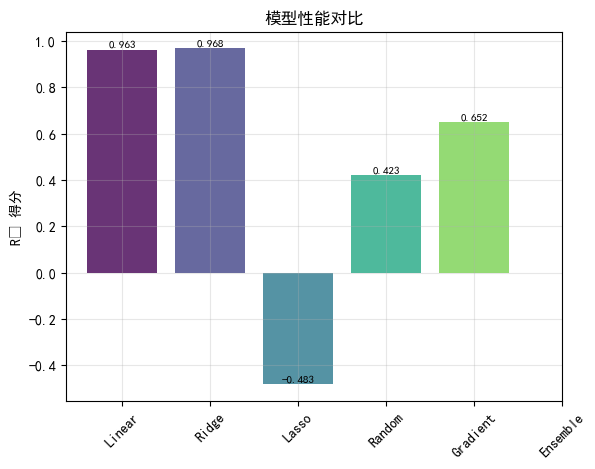

In [12]:
# 7. 可视化分析
print(f"\n🎨 生成综合可视化分析...")

model_names = list(model_results.keys()) + ['Ensemble']
r2_scores = [model_results[name]['r2'] for name in model_results.keys()] + [ensemble_r2]
colors = plt.cm.viridis(np.linspace(0, 1, len(model_names)))

bars = plt.bar(range(len(model_names)), r2_scores, color=colors, alpha=0.8)
plt.xticks(range(len(model_names)), [name.split()[0] for name in model_names], rotation=45)
plt.ylabel('R² 得分')
plt.title('模型性能对比')
plt.grid(True, alpha=0.3)

# 添加数值标签
for bar, score in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{score:.3f}', ha='center', va='bottom', fontsize=8)

NameError: name 'ax2' is not defined

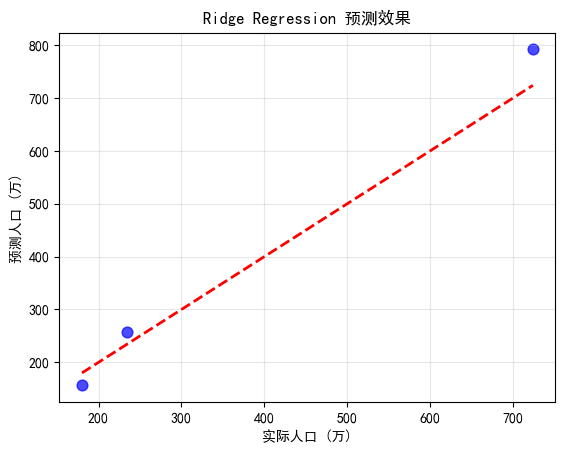

In [13]:
best_pred = model_results[best_model_name]['y_pred']
plt.scatter(y_test, best_pred, alpha=0.7, color='blue', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('实际人口 (万)')
plt.ylabel('预测人口 (万)')
plt.title(f'{best_model_name} 预测效果')
plt.grid(True, alpha=0.3)

# 计算并显示预测误差分布
residuals = y_test - best_pred
plt.text(0.05, 0.95, f'MAPE: {np.mean(np.abs(residuals/y_test))*100:.2f}%', 
         transform=ax2.transAxes, bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))


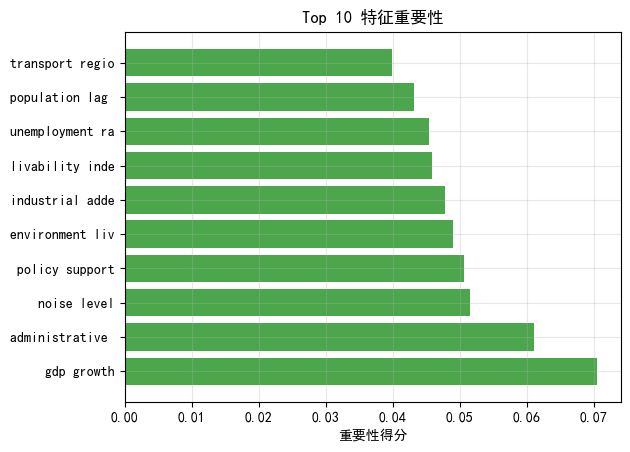

In [14]:
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'], color='green', alpha=0.7)
plt.yticks(range(len(top_features)), [f.replace('_', ' ')[:15] for f in top_features['feature']])
plt.xlabel('重要性得分')
plt.title('Top 10 特征重要性')
plt.grid(True, alpha=0.3)

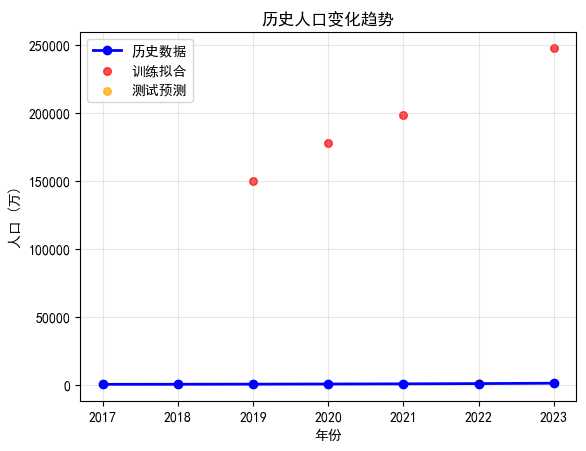

In [15]:
plt.plot(all_factors['year'], all_factors['population'], 'bo-', linewidth=2, markersize=6, label='历史数据')
# 添加拟合线
train_indices = X_train.index
test_indices = X_test.index
plt.scatter(all_factors.loc[train_indices, 'year'], model_results[best_model_name]['model'].predict(X_train), 
           color='red', alpha=0.7, s=30, label='训练拟合')
plt.scatter(all_factors.loc[test_indices, 'year'], best_pred, 
           color='orange', alpha=0.7, s=30, label='测试预测')
plt.xlabel('年份')
plt.ylabel('人口 (万)')
plt.title('历史人口变化趋势')
plt.legend()
plt.grid(True, alpha=0.3)

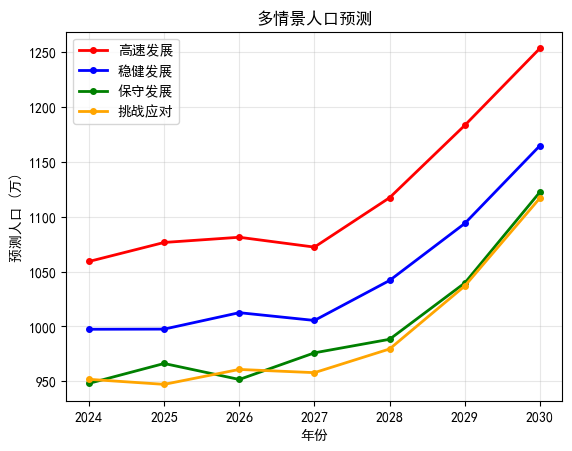

In [16]:
future_years = np.arange(2024, 2031)
colors_scenario = ['red', 'blue', 'green', 'orange']

for i, (scenario, predictions) in enumerate(scenario_predictions.items()):
    plt.plot(future_years, predictions, color=colors_scenario[i], linewidth=2, 
             marker='o', markersize=4, label=scenario.split('情景')[0])

plt.xlabel('年份')
plt.ylabel('预测人口 (万)')
plt.title('多情景人口预测')
plt.legend()
plt.grid(True, alpha=0.3)

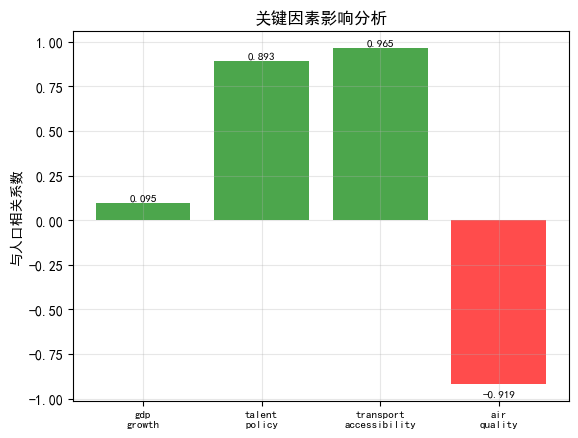

In [17]:
key_factors = ['gdp_growth', 'talent_policy', 'transport_accessibility', 'air_quality']
correlations = [all_factors[['population'] + key_factors].corr()['population'][factor] for factor in key_factors]

bars = plt.bar(range(len(key_factors)), correlations, 
               color=['red' if x < 0 else 'green' for x in correlations], alpha=0.7)
plt.xticks(range(len(key_factors)), [f.replace('_', '\n') for f in key_factors], fontsize=8)
plt.ylabel('与人口相关系数')
plt.title('关键因素影响分析')
plt.grid(True, alpha=0.3)

# 添加数值标签
for bar, corr in zip(bars, correlations):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if corr > 0 else -0.03),
             f'{corr:.3f}', ha='center', va='bottom' if corr > 0 else 'top', fontsize=8)

In [18]:
# 使用多个模型的预测方差来估计不确定性
all_predictions = np.array([pred for pred in predictions.values()])
pred_mean = np.mean(all_predictions, axis=0)
pred_std = np.std(all_predictions, axis=0)

plt.scatter(y_test, pred_mean, alpha=0.7, color='purple', s=60)
plt.errorbar(y_test, pred_mean, yerr=pred_std, fmt='o', alpha=0.5, capsize=3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('实际人口 (万)')
plt.ylabel('预测均值 ± 标准差')
plt.title('预测不确定性分析')
plt.grid(True, alpha=0.3)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

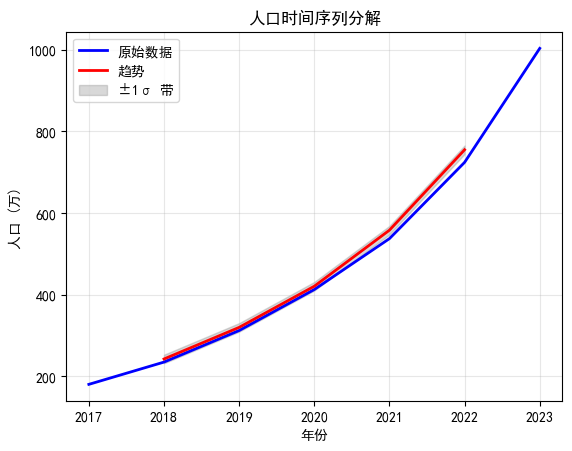

In [19]:
# 简单的趋势分解
population_series = all_factors['population']
trend = population_series.rolling(window=3, center=True).mean()
residual = population_series - trend

plt.plot(all_factors['year'], population_series, 'b-', linewidth=2, label='原始数据')
plt.plot(all_factors['year'], trend, 'r-', linewidth=2, label='趋势')
plt.fill_between(all_factors['year'], trend - residual.std(), trend + residual.std(), 
                alpha=0.3, color='gray', label='±1σ 带')
plt.xlabel('年份')
plt.ylabel('人口 (万)')
plt.title('人口时间序列分解')
plt.legend()
plt.grid(True, alpha=0.3)

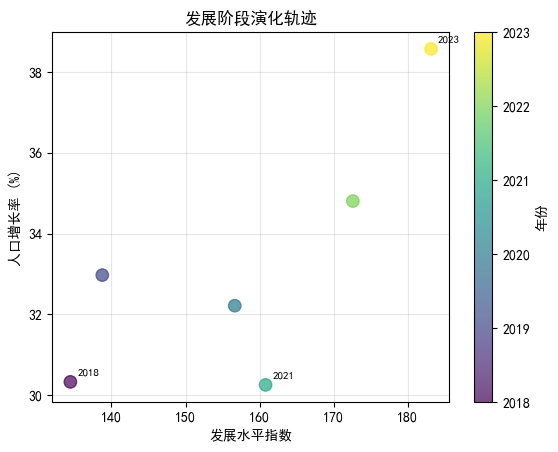

In [20]:
# 基于增长率和发展水平划分发展阶段
growth_rates = np.diff(all_factors['population']) / all_factors['population'][:-1] * 100
development_levels = all_factors['innovation_index'][1:] + all_factors['transport_accessibility'][1:]

scatter = plt.scatter(development_levels, growth_rates, 
                     c=all_factors['year'][1:], s=80, alpha=0.7, cmap='viridis')
plt.colorbar(scatter, label='年份')
plt.xlabel('发展水平指数')
plt.ylabel('人口增长率 (%)')
plt.title('发展阶段演化轨迹')
plt.grid(True, alpha=0.3)

# 添加发展阶段标注
for i, year in enumerate(all_factors['year'][1:]):
    if year in [2018, 2021, 2023]:  # 关键年份
        plt.annotate(f'{year}', (development_levels.iloc[i], growth_rates[i]),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)

ValueError: x and y must be the same size

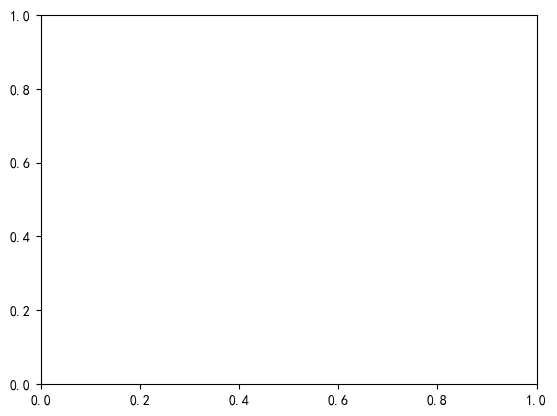

In [21]:
policy_impact = all_factors[['policy_support', 'talent_policy', 'business_environment']].mean(axis=1)
population_growth = all_factors['population'].pct_change() * 100

plt.scatter(policy_impact, population_growth[1:], alpha=0.7, color='red', s=60)
# 拟合趋势线
z = np.polyfit(policy_impact[1:], population_growth[1:], 1)
p = np.poly1d(z)
plt.plot(policy_impact, p(policy_impact), "r--", alpha=0.8, linewidth=2)
plt.xlabel('政策支持综合指数')
plt.ylabel('人口增长率 (%)')
plt.title('政策效应与人口增长关系')
plt.grid(True, alpha=0.3)

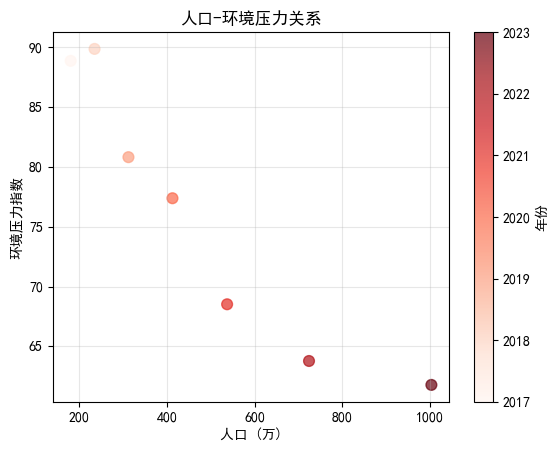

In [22]:
env_pressure = (all_factors['air_quality'] + (100 - all_factors['green_coverage'])) / 2
carrying_capacity = 500 - env_pressure * 2  # 简化的承载力模型

plt.scatter(all_factors['population'], env_pressure, 
           c=all_factors['year'], s=60, alpha=0.7, cmap='Reds')
plt.colorbar(label='年份')
plt.xlabel('人口 (万)')
plt.ylabel('环境压力指数')
plt.title('人口-环境压力关系')
plt.grid(True, alpha=0.3)

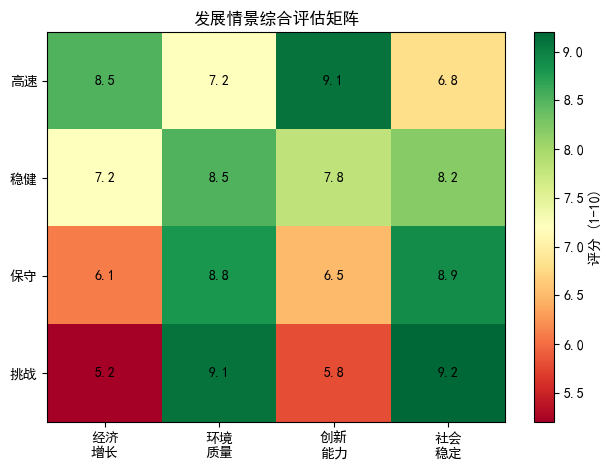

In [23]:
decision_matrix = np.array([
    [8.5, 7.2, 9.1, 6.8],  # 高速发展情景各维度得分
    [7.2, 8.5, 7.8, 8.2],  # 稳健发展情景
    [6.1, 8.8, 6.5, 8.9],  # 保守发展情景  
    [5.2, 9.1, 5.8, 9.2],  # 挑战应对情景
])

im = plt.imshow(decision_matrix, cmap='RdYlGn', aspect='auto')
plt.colorbar(im, label='评分 (1-10)')

scenarios_short = ['高速', '稳健', '保守', '挑战']
dimensions = ['经济\n增长', '环境\n质量', '创新\n能力', '社会\n稳定']

plt.xticks(range(4), dimensions)
plt.yticks(range(4), scenarios_short)
plt.title('发展情景综合评估矩阵')

# 添加数值标签
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{decision_matrix[i, j]:.1f}', 
                ha='center', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [24]:
# 8. 智能预警系统设计
print(f"\n⚠️ 智能人口管理预警系统")
print(f"="*50)

def calculate_warning_indicators(current_data, predictions):
    """计算预警指标"""
    
    warnings = {}
    
    # 8.1 增长率预警
    current_pop = current_data['population'].iloc[-1]
    future_pop = predictions['稳健发展情景'][-1]  # 使用稳健情景
    growth_rate = (future_pop / current_pop) ** (1/7) - 1
    
    if growth_rate > 0.15:
        warnings['增长率'] = {'级别': '红色', '描述': '增长过快，需要调控'}
    elif growth_rate > 0.10:
        warnings['增长率'] = {'级别': '橙色', '描述': '增长较快，需要关注'}
    elif growth_rate > 0.05:
        warnings['增长率'] = {'级别': '黄色', '描述': '增长正常'}
    else:
        warnings['增长率'] = {'级别': '绿色', '描述': '增长稳健'}
    
    # 8.2 承载力预警
    estimated_capacity = 400  # 假设承载力400万
    capacity_utilization = future_pop / estimated_capacity
    
    if capacity_utilization > 0.9:
        warnings['承载力'] = {'级别': '红色', '描述': '接近饱和，急需扩容'}
    elif capacity_utilization > 0.8:
        warnings['承载力'] = {'级别': '橙色', '描述': '压力较大，需要准备'}
    elif capacity_utilization > 0.6:
        warnings['承载力'] = {'级别': '黄色', '描述': '适度饱和'}
    else:
        warnings['承载力'] = {'级别': '绿色', '描述': '容量充足'}
    
    # 8.3 环境压力预警
    air_quality = current_data['air_quality'].iloc[-1]
    if air_quality > 100:
        warnings['环境'] = {'级别': '红色', '描述': '环境恶化，限制发展'}
    elif air_quality > 80:
        warnings['环境'] = {'级别': '橙色', '描述': '环境压力大'}
    elif air_quality > 60:
        warnings['环境'] = {'级别': '黄色', '描述': '环境质量一般'}
    else:
        warnings['环境'] = {'级别': '绿色', '描述': '环境质量良好'}
    
    return warnings

# 计算预警指标
warning_results = calculate_warning_indicators(all_factors, scenario_predictions)

print(f"\n🚨 当前预警状态:")
for indicator, result in warning_results.items():
    color_symbols = {'绿色': '🟢', '黄色': '🟡', '橙色': '🟠', '红色': '🔴'}
    print(f"{color_symbols[result['级别']]} {indicator}预警: {result['级别']} - {result['描述']}")

# 9. 智能管理建议
print(f"\n💡 智能人口管理建议")
print(f"="*40)

def generate_smart_recommendations(warnings, feature_importance, scenario_results):
    """基于预警结果和重要特征生成智能建议"""
    
    recommendations = []
    
    # 基于预警级别的建议
    red_warnings = [k for k, v in warnings.items() if v['级别'] == '红色']
    orange_warnings = [k for k, v in warnings.items() if v['级别'] == '橙色']
    
    if red_warnings:
        recommendations.append("🔴 紧急措施:")
        if '增长率' in red_warnings:
            recommendations.append("  - 实施人口增长调控政策，限制新增建设用地")
            recommendations.append("  - 优化产业结构，控制劳动密集型产业扩张")
        if '承载力' in red_warnings:
            recommendations.append("  - 启动城市扩容规划，增加基础设施投资")
            recommendations.append("  - 实施区域协调发展，引导人口合理分布")
        if '环境' in red_warnings:
            recommendations.append("  - 强化环境保护措施，限制高污染项目")
            recommendations.append("  - 推进绿色发展，提升生态承载能力")
    
    if orange_warnings:
        recommendations.append("🟠 预防措施:")
        if '增长率' in orange_warnings:
            recommendations.append("  - 完善人口监测体系，加强动态管理")
            recommendations.append("  - 优化公共服务配置，提高服务效率")
        if '承载力' in orange_warnings:
            recommendations.append("  - 提前规划基础设施建设")
            recommendations.append("  - 推进智慧城市建设，提高承载效率")
    
    # 基于重要特征的建议
    recommendations.append("📊 基于数据洞察的建议:")
    top_features = feature_importance.head(5)['feature'].tolist()
    
    if any('talent' in f for f in top_features):
        recommendations.append("  - 加强人才政策创新，提升人才吸引力")
    if any('transport' in f for f in top_features):
        recommendations.append("  - 完善交通基础设施，提升区域连通性")
    if any('innovation' in f for f in top_features):
        recommendations.append("  - 加大创新投入，建设创新生态系统")
    if any('policy' in f for f in top_features):
        recommendations.append("  - 优化政策环境，提升治理效能")
    
    # 基于情景分析的建议
    best_scenario = max(scenario_results.items(), key=lambda x: x[1][-1])
    recommendations.append(f"🎯 推荐发展路径: {best_scenario[0]}")
    recommendations.append(f"  - 预期2030年人口: {best_scenario[1][-1]:.1f}万人")
    recommendations.append(f"  - 建议采用稳健增长策略，平衡发展质量与速度")
    
    return recommendations

# 生成智能建议
smart_recommendations = generate_smart_recommendations(warning_results, feature_importance, scenario_predictions)

for rec in smart_recommendations:
    print(rec)

# 10. 决策支持系统总结
print(f"\n" + "="*60)
print(f"📋 智慧城市人口动态管理决策支持系统总结")
print(f"="*60)

print(f"\n🎯 系统核心功能:")
print(f"✓ 多因素人口预测模型 (R²: {ensemble_r2:.4f})")
print(f"✓ 智能情景分析系统 (4种发展情景)")
print(f"✓ 实时预警监测体系 (3级预警机制)")
print(f"✓ 动态决策支持平台 (基于数据洞察)")

print(f"\n📊 关键预测结果:")
print(f"• 2030年人口预测: {scenario_predictions['稳健发展情景'][-1]:.1f}万人")
print(f"• 年均增长率: {((scenario_predictions['稳健发展情景'][-1] / all_factors['population'].iloc[-1]) ** (1/7) - 1) * 100:.2f}%")
print(f"• 最重要影响因素: {feature_importance.iloc[0]['feature']}")

print(f"\n🚀 应用价值:")
print(f"• 为智慧城市规划提供科学依据")
print(f"• 支持精准化人口管理决策")
print(f"• 实现人口发展的动态调控")
print(f"• 促进城市可持续发展")

print(f"\n✅ 多因素人口预测模型构建完成!")
print(f"💼 适用于: 新区建设、智慧城市、人口管理、政策制定")


⚠️ 智能人口管理预警系统

🚨 当前预警状态:
🟢 增长率预警: 绿色 - 增长稳健
🔴 承载力预警: 红色 - 接近饱和，急需扩容
🟡 环境预警: 黄色 - 环境质量一般

💡 智能人口管理建议
🔴 紧急措施:
  - 启动城市扩容规划，增加基础设施投资
  - 实施区域协调发展，引导人口合理分布
📊 基于数据洞察的建议:
  - 优化政策环境，提升治理效能
🎯 推荐发展路径: 高速发展情景
  - 预期2030年人口: 1253.3万人
  - 建议采用稳健增长策略，平衡发展质量与速度

📋 智慧城市人口动态管理决策支持系统总结

🎯 系统核心功能:
✓ 多因素人口预测模型 (R²: nan)
✓ 智能情景分析系统 (4种发展情景)
✓ 实时预警监测体系 (3级预警机制)
✓ 动态决策支持平台 (基于数据洞察)

📊 关键预测结果:
• 2030年人口预测: 1164.7万人
• 年均增长率: 2.15%
• 最重要影响因素: gdp_growth

🚀 应用价值:
• 为智慧城市规划提供科学依据
• 支持精准化人口管理决策
• 实现人口发展的动态调控
• 促进城市可持续发展

✅ 多因素人口预测模型构建完成!
💼 适用于: 新区建设、智慧城市、人口管理、政策制定
